# Luxury Beauty Cosmetics Pop-Up Events Analysis
**Tools:** Python, pandas, matplotlib, SQLite  
**Dataset:** 2,133 luxury beauty pop-up events across global retail locations (2025)  
**Goal:** Identify top-performing regions, venue types, and brands by revenue and sell-through rate.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [2]:
df = pd.read_csv('luxury_cosmetics_popups.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (2133, 15)

Column names:
 ['event_id', 'brand', 'region', 'city', 'location_type', 'event_type', 'start_date', 'end_date', 'lease_length_days', 'sku', 'product_name', 'price_usd', 'avg_daily_footfall', 'units_sold', 'sell_through_pct']

Missing values:
 event_id               0
brand                  0
region                 0
city                  47
location_type          0
event_type             0
start_date             0
end_date              36
lease_length_days      0
sku                    0
product_name           0
price_usd              0
avg_daily_footfall     0
units_sold             0
sell_through_pct       0
dtype: int64


,event_id,brand,region,city,location_type,event_type,start_date,end_date,lease_length_days,sku,product_name,price_usd,avg_daily_footfall,units_sold,sell_through_pct
0,POP100282,Charlotte Tilbury,North America,Miami,Art/Design District,Flash Event,2024-02-25,2024-03-02,6,LE-UQYNQA1A,Charlotte Tilbury Glow Mascara,62.21,1107,3056,98.90
1,POP102014,Valentino Beauty,North America,New York,Airport Duty-Free,Flash Event,2024-03-17,2024-06-09,84,LE-9E9FTDSM,Valentino Beauty Pearl Eyeshadow Palette,77.93,1652,2782,86.32
2,POP101719,YSL Beauty,Europe,Berlin,Airport Duty-Free,Standalone Pop-Up,2025-02-26,2025-03-10,12,LE-W921CLUG,YSL Beauty Glow Eyeshadow Palette,149.91,752,2720,69.18
3,POP100994,Hermès Beauty,North America,Chicago,Airport Duty-Free,Standalone Pop-Up,2025-07-06,2025-08-04,29,LE-MPO4BX6H,Hermès Beauty Pearl Highlighter,80.32,1688,203,66.78
4,POP102033,Tom Ford Beauty,Europe,London,High-Street,Shop-in-Shop,2024-12-06,2024-12-25,19,LE-M3D94MYP,Tom Ford Beauty Noir Highlighter,56.15,1012,1292,80.10


In [3]:
# Fix date columns
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

# Create a revenue column
df['total_revenue'] = df['units_sold'] * df['price_usd']

# Drop rows where city is null
df_clean = df.dropna(subset=['city'])

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print("\nSample revenue values:")
df_clean[['brand', 'city', 'total_revenue']].head()

Rows before cleaning: 2133
Rows after cleaning: 2086

Sample revenue values:


,brand,city,total_revenue
0,Charlotte Tilbury,Miami,190113.76
1,Valentino Beauty,New York,216801.26
2,YSL Beauty,Berlin,407755.20
3,Hermès Beauty,Chicago,16304.96
4,Tom Ford Beauty,London,72545.80


In [4]:
conn = sqlite3.connect(':memory:')
df_clean.to_sql('popups', conn, if_exists='replace', index=False)

q1 = pd.read_sql("""
    SELECT region, ROUND(SUM(total_revenue), 2) AS total_revenue
    FROM popups
    GROUP BY region
    ORDER BY total_revenue DESC
""", conn)
print("Revenue by Region:")
print(q1)

Revenue by Region:
          region  total_revenue
0         Europe    87530327.26
1  Latin America    84962904.59
2    Middle East    74955092.75
3  North America    72947280.39
4   Asia-Pacific    72196558.96


In [5]:
q2 = pd.read_sql("""
    SELECT location_type, ROUND(AVG(sell_through_pct), 2) AS avg_sell_through
    FROM popups
    GROUP BY location_type
    ORDER BY avg_sell_through DESC
""", conn)
print("Sell-Through by Venue Type:")
print(q2)

Sell-Through by Venue Type:
             location_type  avg_sell_through
0              High-Street             74.09
1        Airport Duty-Free             73.81
2  Department Store Atrium             73.13
3      Art/Design District             72.97
4              Luxury Mall             72.01


In [6]:
q3 = pd.read_sql("""
    SELECT brand, ROUND(SUM(total_revenue), 2) AS total_revenue
    FROM popups
    GROUP BY brand
    ORDER BY total_revenue DESC
    LIMIT 5
""", conn)
print("Top 5 Brands by Revenue:")
print(q3)

Top 5 Brands by Revenue:
          brand  total_revenue
0  Estée Lauder    20657473.39
1    YSL Beauty    20180891.81
2  Sisley-Paris    18719638.39
3   Rare Beauty    18512901.07
4     Hourglass    18291225.32


In [7]:
q4 = pd.read_sql("""
    SELECT event_type,
           ROUND(SUM(units_sold) * 1.0 / SUM(avg_daily_footfall * lease_length_days), 4) AS footfall_conversion_rate
    FROM popups
    GROUP BY event_type
    ORDER BY footfall_conversion_rate DESC
""", conn)
print("Footfall Conversion by Event Type:")
print(q4)

Footfall Conversion by Event Type:
            event_type  footfall_conversion_rate
0  Mobile Pop-Up Truck                    0.0310
1          Flash Event                    0.0307
2    Standalone Pop-Up                    0.0289
3         Shop-in-Shop                    0.0281
4           Mall Kiosk                    0.0280


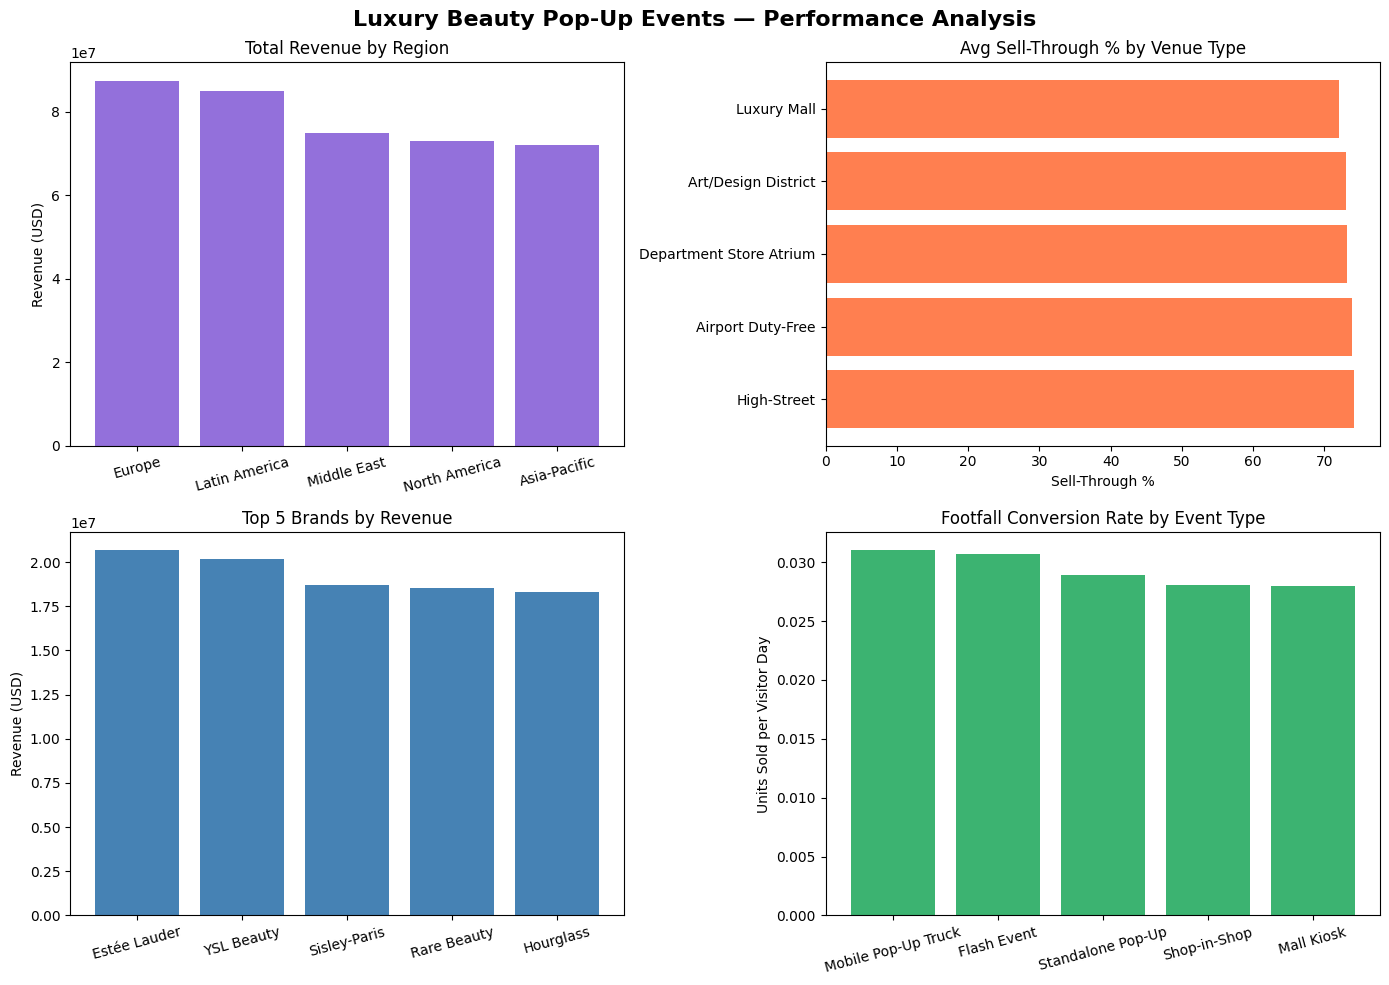

Chart saved ✅


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Luxury Beauty Pop-Up Events — Performance Analysis', fontsize=16, fontweight='bold')

# Chart 1: Revenue by Region
axes[0,0].bar(q1['region'], q1['total_revenue'], color='mediumpurple')
axes[0,0].set_title('Total Revenue by Region')
axes[0,0].set_ylabel('Revenue (USD)')
axes[0,0].tick_params(axis='x', rotation=15)

# Chart 2: Sell-Through by Venue Type
axes[0,1].barh(q2['location_type'], q2['avg_sell_through'], color='coral')
axes[0,1].set_title('Avg Sell-Through % by Venue Type')
axes[0,1].set_xlabel('Sell-Through %')

# Chart 3: Top 5 Brands by Revenue
axes[1,0].bar(q3['brand'], q3['total_revenue'], color='steelblue')
axes[1,0].set_title('Top 5 Brands by Revenue')
axes[1,0].set_ylabel('Revenue (USD)')
axes[1,0].tick_params(axis='x', rotation=15)

# Chart 4: Footfall Conversion by Event Type
axes[1,1].bar(q4['event_type'], q4['footfall_conversion_rate'], color='mediumseagreen')
axes[1,1].set_title('Footfall Conversion Rate by Event Type')
axes[1,1].set_ylabel('Units Sold per Visitor Day')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('popup_analysis.png', dpi=150)
plt.show()
print("Chart saved ✅")

## Key Findings

1. **Regional Revenue:** Europe leads all regions with 87.5M USD in total revenue,
followed closely by Latin America at 85M USD
3. **Best Venue:** High-Street locations have the highest sell-through rate at
74.09%, making them the most effective venue type
4. **Top Brand:** Estée Lauder drives the most revenue at 20.6M USD across all events,
followed by YSL Beauty at 20.2M USD
5. **Best Event Format:** Mobile Pop-Up Trucks convert foot traffic to sales most
efficiently at a 3.10% conversion rate

## Recommendations
- **Prioritize Europe and Latin America** for future pop-up activations given
highest revenue concentration
- **Focus on High-Street locations** to maximize sell-through rates
- **Use Mobile Pop-Up Trucks and Flash Events** for highest footfall-to-sales conversion
- **Partner with Estée Lauder and YSL Beauty** for co-branded activations given
their dominant revenue performance